# A3 — Baseline Models

**Aim:** evaluate baseline predictability of Kp ≥ 5 targets using frozen features/targets and a walk-forward split.
This notebook performs classification only (no continuous Kp regression).


In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd


In [12]:
DATA_DIR = Path("../Data")
FEATURES_PATH = DATA_DIR / "processed" / "features.parquet"
TARGETS_PATH = DATA_DIR / "processed" / "targets.parquet"

features_df = pd.read_parquet(FEATURES_PATH)
targets_df = pd.read_parquet(TARGETS_PATH)

# Align on the timestamp index
features_df = features_df.sort_index()
targets_df = targets_df.sort_index()
features_df = features_df.loc[targets_df.index]

if not features_df.index.equals(targets_df.index):
    raise ValueError("Feature/target index mismatch")


In [13]:
HORIZONS = ["3h", "6h", "12h", "24h", "48h", "72h", "96h"]
target_cols = [f"target_{h}" for h in HORIZONS]
missing = [c for c in target_cols if c not in targets_df.columns]
if missing:
    raise KeyError(f"Missing target columns: {missing}")


In [14]:
# Walk-forward split: 60% / 20% / 20%
n = len(targets_df)
train_end = int(0.6 * n)
val_end = int(0.8 * n)

idx = targets_df.index
train_idx = idx[:train_end]
val_idx = idx[train_end:val_end]
test_idx = idx[val_end:]

splits = {
    "train": train_idx,
    "val": val_idx,
    "test": test_idx,
}

print("Rows per split:")
for name, split_idx in splits.items():
    start = split_idx[0]
    end = split_idx[-1]
    print(f"  {name}: {len(split_idx)} rows ({start} → {end})")

print("\nEvent rate per split (per horizon):")
for name, split_idx in splits.items():
    rates = targets_df.loc[split_idx, target_cols].mean()
    rates = rates.rename(lambda c: c.replace("target_", ""))
    print(f"\n{name}")
    print(rates)


Rows per split:
  train: 50789 rows (1997-01-01 00:00:00+00:00 → 2014-05-20 12:00:00+00:00)
  val: 16930 rows (2014-05-20 15:00:00+00:00 → 2020-03-05 18:00:00+00:00)
  test: 16930 rows (2020-03-05 21:00:00+00:00 → 2025-12-21 00:00:00+00:00)

Event rate per split (per horizon):

train
3h     0.030656
6h     0.044557
12h    0.067141
24h    0.104393
48h    0.167339
72h    0.223592
96h    0.274233
dtype: float64

val
3h     0.020024
6h     0.030833
12h    0.047608
24h    0.076905
48h    0.128884
72h    0.177968
96h    0.223804
dtype: float64

test
3h     0.024631
6h     0.036385
12h    0.055936
24h    0.090077
48h    0.150620
72h    0.207147
96h    0.258771
dtype: float64


## Part 2 — Baseline Models (No Tuning)

We fit Logistic Regression, RandomForest, and XGBoost on the training split only.
LogReg/RandomForest use median imputation; XGBoost uses raw NaNs.


In [15]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed; XGBoost model will be skipped.")


In [16]:
RANDOM_STATE = 42

def build_models():
    models = {
        "logreg": make_pipeline(
            SimpleImputer(strategy="median"),
            StandardScaler(),
            LogisticRegression(max_iter=1000, class_weight=None, random_state=RANDOM_STATE),
        ),
        "logreg_balanced": make_pipeline(
            SimpleImputer(strategy="median"),
            StandardScaler(),
            LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
        ),
        "random_forest": make_pipeline(
            SimpleImputer(strategy="median"),
            RandomForestClassifier(random_state=RANDOM_STATE),
        ),
    }
    if HAS_XGB:
        models["xgboost"] = xgb.XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss",
        )
    return models

trained_models = {}

X_train = features_df.loc[train_idx]

for h in HORIZONS:
    y_train = targets_df.loc[train_idx, f"target_{h}"]
    models = build_models()
    trained_models[h] = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        trained_models[h][name] = model

    print(f"Trained models for horizon {h}: {list(trained_models[h].keys())}")


Trained models for horizon 3h: ['logreg', 'logreg_balanced', 'random_forest', 'xgboost']
Trained models for horizon 6h: ['logreg', 'logreg_balanced', 'random_forest', 'xgboost']
Trained models for horizon 12h: ['logreg', 'logreg_balanced', 'random_forest', 'xgboost']
Trained models for horizon 24h: ['logreg', 'logreg_balanced', 'random_forest', 'xgboost']
Trained models for horizon 48h: ['logreg', 'logreg_balanced', 'random_forest', 'xgboost']
Trained models for horizon 72h: ['logreg', 'logreg_balanced', 'random_forest', 'xgboost']
Trained models for horizon 96h: ['logreg', 'logreg_balanced', 'random_forest', 'xgboost']


## Part 3 — Evaluation Metrics

Compute ROC-AUC, PR-AUC, and Brier score for each model × horizon × split.


In [23]:
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score

def predict_proba_safe(model, X):
    # Some sklearn pipelines expose predict_proba; XGBoost does too.
    proba = model.predict_proba(X)[:, 1]
    return proba

rows = []

for h in HORIZONS:
    for split_name, split_idx in splits.items():
        X_split = features_df.loc[split_idx]
        y_split = targets_df.loc[split_idx, f"target_{h}"]

        for model_name, model in trained_models[h].items():
            y_proba = predict_proba_safe(model, X_split)
            roc = roc_auc_score(y_split, y_proba)
            pr_auc = average_precision_score(y_split, y_proba)
            brier = brier_score_loss(y_split, y_proba)
            rows.append({
                "horizon": h,
                "model": model_name,
                "split": split_name,
                "roc_auc": roc,
                "pr_auc": pr_auc,
                "brier": brier,
            })

results_df = pd.DataFrame(rows)
results_df


,horizon,model,split,roc_auc,pr_auc,brier
0,3h,logreg,train,0.929303,0.463058,0.021609
1,3h,logreg_balanced,train,0.932687,0.449617,0.098978
2,3h,random_forest,train,1.000000,1.000000,0.002988
3,3h,xgboost,train,0.999683,0.993488,0.003734
4,3h,logreg,val,0.936919,0.350044,0.015832
...,...,...,...,...,...,...
79,96h,xgboost,val,0.610449,0.329342,0.185137
80,96h,logreg,test,0.654570,0.413729,0.180914
81,96h,logreg_balanced,test,0.654625,0.412136,0.236690
82,96h,random_forest,test,0.645456,0.407632,0.184481


In [33]:
# Save results table
results_path = Path("../Data") / "processed" / "results_baseline.csv"
results_df.to_csv(results_path, index=False)
print(f"Saved: {results_path}")


Saved: ../Data/processed/results_baseline.csv


### Calibration (24h horizon)

Reliability curve on the test split for 24h.


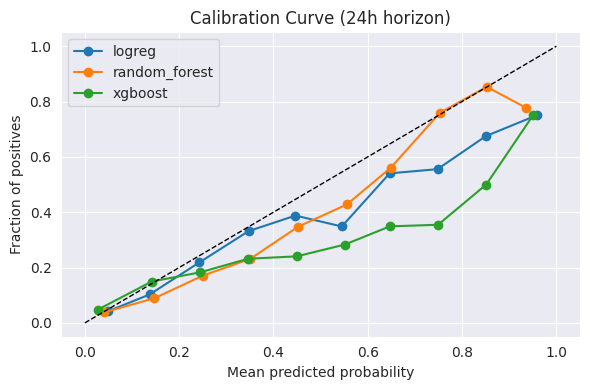

In [34]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

h = "24h"
split_idx = splits["test"]
X_test = features_df.loc[split_idx]
y_test = targets_df.loc[split_idx, f"target_{h}"]

plt.figure(figsize=(6, 4))

for model_name, model in trained_models[h].items():
    if model_name not in {"logreg", "random_forest", "xgboost"}:
        continue
    y_proba = predict_proba_safe(model, X_test)
    frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10)
    plt.plot(mean_pred, frac_pos, marker="o", label=model_name)

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.title("Calibration Curve (24h horizon)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.legend()
plt.tight_layout()
plt.show()


 - Dashed line = perfect calibration (predicted probability = observed event rate).
  - Points above the line = model under‑predicts (true rate higher than predicted).
  - Points below the line = model over‑predicts (true rate lower than predicted).

  From the plot:

  - LogReg (blue): fairly close to the diagonal in low–mid probabilities, but tends to
    under‑predict at higher probabilities (points above the line near 0.7–0.9).
  - RandomForest (orange): close in mid‑range, then over‑predicts at the top end (points
    below the line near 0.9–1.0).
  - XGBoost (green): tends to over‑predict in mid‑to‑high ranges (points below the line),
    meaning it’s a bit too confident.

  Overall: none are perfectly calibrated; LogReg looks most stable in the mid‑range, RF is
  good until the highest bins, XGBoost is more over‑confident.


## Part 4 — Horizon Sweep Analysis

Plot ROC-AUC and Brier vs horizon on the test split.


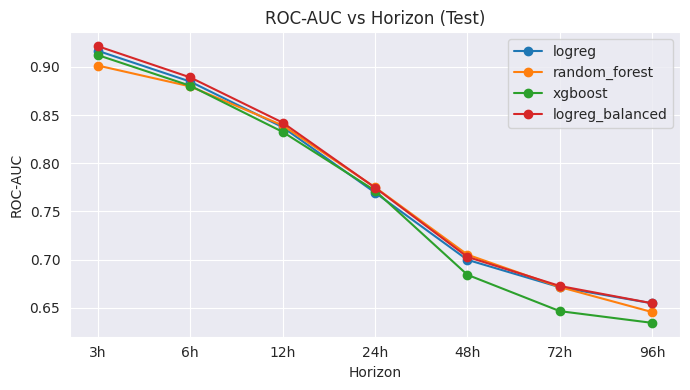

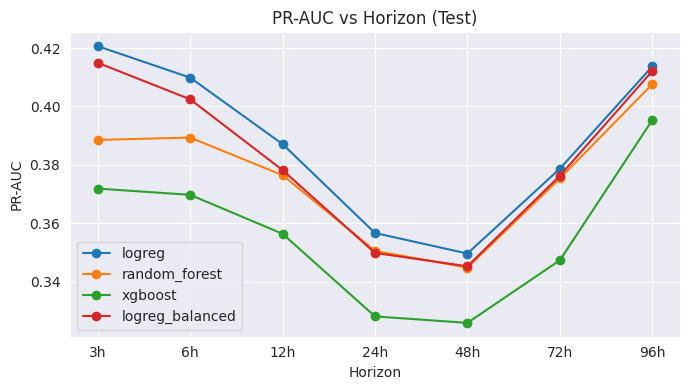

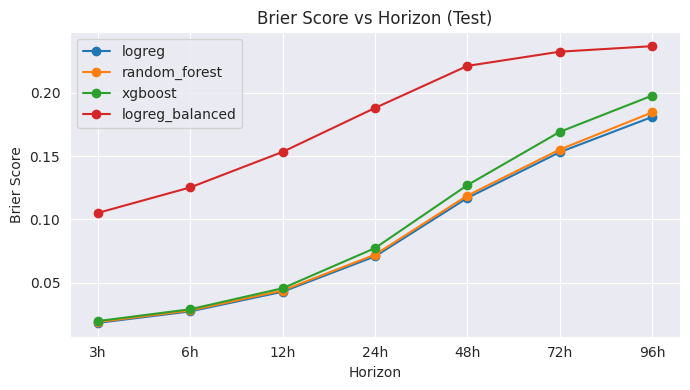

In [35]:
 import matplotlib.pyplot as plt

test_df = results_df[results_df["split"] == "test"].copy()
model_order = ["logreg", "random_forest", "xgboost", "logreg_balanced"]

# ROC-AUC vs horizon
plt.figure(figsize=(7, 4))
for model_name in model_order:
    if model_name not in test_df["model"].unique():
        continue
    sub = test_df[test_df["model"] == model_name]
    plt.plot(sub["horizon"], sub["roc_auc"], marker="o", label=model_name)

plt.title("ROC-AUC vs Horizon (Test)")
plt.xlabel("Horizon")
plt.ylabel("ROC-AUC")
plt.legend()
plt.tight_layout()
plt.show()

# PR-AUC vs horizon
plt.figure(figsize=(7, 4))
for model_name in model_order:
    if model_name not in test_df["model"].unique():
        continue
    sub = test_df[test_df["model"] == model_name]
    plt.plot(sub["horizon"], sub["pr_auc"], marker="o", label=model_name)

plt.title("PR-AUC vs Horizon (Test)")
plt.xlabel("Horizon")
plt.ylabel("PR-AUC")
plt.legend()
plt.tight_layout()
plt.show()

# Brier vs horizon
plt.figure(figsize=(7, 4))
for model_name in model_order:
    if model_name not in test_df["model"].unique():
        continue
    sub = test_df[test_df["model"] == model_name]
    plt.plot(sub["horizon"], sub["brier"], marker="o", label=model_name)

plt.title("Brier Score vs Horizon (Test)")
plt.xlabel("Horizon")
plt.ylabel("Brier Score")
plt.legend()
plt.tight_layout()
plt.show()




   ROC‑AUC vs Horizon (Test)

  - Skill drops steadily as horizon increases.
  - LogReg ≈ RandomForest, with XGBoost slightly weaker at long horizons.
  - Class‑weighted LogReg is close to standard LogReg.

  PR‑AUC vs Horizon (Test)

  - PR‑AUC falls from 3h to ~24–48h, then rises at 72–96h because event rate increases.
  - LogReg and RandomForest stay on top; XGBoost is lowest.
  - Curve shape reflects class imbalance changes across horizons.

  Brier Score vs Horizon (Test)

  - Brier score increases with horizon (probability accuracy worsens).
  - LogReg and RandomForest are lowest (best).
  - LogReg‑balanced is consistently worse (over‑confident probabilities).
  - XGBoost is slightly worse than LogReg/RF at longer horizons.

  Global comment
  Overall predictability is strongest at short horizons and degrades with lead time. LogReg
  and RandomForest provide the most reliable baseline performance, while XGBoost
  underperforms slightly at longer horizons. Probability calibration worsens with horizon
  and class‑weighted LogReg hurts Brier despite similar ROC‑AUC. These plots establish a
  clean baseline for future tuning and feature expansion.




## Part 5 — Final Baseline Summary

### Performance table (test split)

Each row is model × horizon with ROC-AUC and Brier on the test set.


In [36]:
summary_df = (
    results_df[results_df["split"] == "test"]
    .pivot_table(index="horizon", columns="model", values=["roc_auc", "pr_auc", "brier"])
)
summary_df


brier                                            pr_auc  \
model      logreg logreg_balanced random_forest   xgboost    logreg   
horizon                                                               
12h      0.042983        0.153302      0.043955  0.045735  0.387101   
24h      0.070861        0.187953      0.072209  0.077405  0.356630   
3h       0.018420        0.105148      0.019029  0.019843  0.420675   
48h      0.117003        0.221132      0.118856  0.127098  0.349591   
6h       0.027469        0.125264      0.028203  0.029175  0.409891   
72h      0.153088        0.232339      0.155167  0.169127  0.378670   
96h      0.180914        0.236690      0.184481  0.197729  0.413729   

                                                  roc_auc                  \
model   logreg_balanced random_forest   xgboost    logreg logreg_balanced   
horizon                                                                     
12h            0.378188      0.376440  0.356355  0.837423        0.842137   
24h            0.349794      0.350493  0.328040  0.769501        0.774651   
3h             0.414986      0.388536  0.371855  0.916623        0.921425   
48h            0.345224      0.344769  0.325820  0.699706        0.702728   
6h             0.402460      0.389348  0.369716  0.884694        0.889035   
72h            0.376261      0.375315  0.347282  0.671270        0.672568   
96h            0.412136      0.407632  0.395327  0.654570        0.654625   

                                 
model   random_forest   xgboost  
horizon                          
12h          0.839243  0.832500  
24h          0.775026  0.771542  
3h           0.901335  0.912189  
48h          0.705097  0.684151  
6h           0.879676  0.880371  
72h          0.671457  0.646457  
96h          0.645456  0.634280

Baseline results confirm the task is a rare‑event classification problem with strong
  horizon decay: skill is highest at short lead times and steadily weakens through 96h.
  LogReg and RandomForest perform similarly across horizons, while XGBoost is slightly
  weaker at long horizons. Calibration is best for LogReg; RandomForest tends to distort
  high‑probability bins and XGBoost is over‑confident in the mid/high range.

  These outcomes are expected for an untuned baseline: the purpose is to establish a clean
  reference ceiling, not to maximize performance. Future work should focus on (1) tuning
  tree models, (2) adding physics‑motivated features, and (3) interpreting drivers with
  feature importance/SHAP, all benchmarked against this baseline.
